In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

RAW = r"C:\Users\Lubov\Downloads\olist_project\data\raw\\"

# з бази
order_items = pd.read_sql("SELECT * FROM order_items", engine)
customers = pd.read_sql("SELECT * FROM customers", engine)
products = pd.read_sql("SELECT * FROM products", engine)
sellers = pd.read_sql("SELECT * FROM sellers", engine)
reviews = pd.read_sql("SELECT * FROM order_reviews", engine)
payments = pd.read_sql("SELECT * FROM order_payments", engine)

# orders з CSV + нові колонки
orders = pd.read_csv(RAW + "olist_orders_dataset.csv")
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "order_delivered_carrier_date",
    "order_approved_at"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

orders["delivery_delay_days"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days
orders["delivery_days_actual"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days
orders["delivery_days_estimated"] = (orders["order_estimated_delivery_date"] - orders["order_purchase_timestamp"]).dt.days
orders["is_late"] = (orders["delivery_delay_days"] > 0).astype("Int64")
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders["order_year"] = orders["order_purchase_timestamp"].dt.year

print("✅ Всі таблиці завантажено")

✅ Всі таблиці завантажено


In [2]:
tables = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "reviews": reviews,
    "payments": payments,
}

print(f"{'Таблиця':<20} {'Рядків':>10} {'Колонок':>10}")
print("-" * 42)
for name, df in tables.items():
    print(f"{name:<20} {len(df):>10} {len(df.columns):>10}")

Таблиця                  Рядків    Колонок
------------------------------------------
orders                    99441         14
order_items              112650          7
customers                 99441          5
products                  32951          9
sellers                    3095          4
reviews                   98410          8
payments                 103886          5


In [3]:
print("=" * 60)
print("ПРОПУЩЕНІ ЗНАЧЕННЯ (NULL)")
print("=" * 60)

for name, df in tables.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]

    if len(nulls) > 0:
        print(f"\n⚠️  {name}:")
        for col, count in nulls.items():
            pct = round(count / len(df) * 100, 1)
            print(f"   {col:<45} {count:>6} рядків ({pct}%)")
    else:
        print(f"\n✅ {name}: пропусків немає")

ПРОПУЩЕНІ ЗНАЧЕННЯ (NULL)

⚠️  orders:
   order_approved_at                                160 рядків (0.2%)
   order_delivered_carrier_date                    1783 рядків (1.8%)
   order_delivered_customer_date                   2965 рядків (3.0%)
   delivery_delay_days                             2965 рядків (3.0%)
   delivery_days_actual                            2965 рядків (3.0%)

✅ order_items: пропусків немає

✅ customers: пропусків немає

⚠️  products:
   product_name_lenght                              610 рядків (1.9%)
   product_description_lenght                       610 рядків (1.9%)
   product_photos_qty                               610 рядків (1.9%)
   product_weight_g                                   2 рядків (0.0%)
   product_length_cm                                  2 рядків (0.0%)
   product_height_cm                                  2 рядків (0.0%)
   product_width_cm                                   2 рядків (0.0%)

✅ sellers: пропусків немає

⚠️  reviews:
  

In [4]:
print("=" * 60)
print("ДУБЛІКАТИ")
print("=" * 60)

checks = {
    "orders": ("order_id",    orders),
    "customers": ("customer_id", customers),
    "products": ("product_id",  products),
    "sellers": ("seller_id",   sellers),
    "reviews": ("review_id",   reviews),
}

for name, (key_col, df) in checks.items():
    total  = len(df)
    unique = df[key_col].nunique()
    dupes  = total - unique

    if dupes > 0:
        print(f"⚠️  {name}: {dupes} дублікатів по '{key_col}'")
    else:
        print(f"✅ {name}: дублікатів немає по '{key_col}'")

ДУБЛІКАТИ
✅ orders: дублікатів немає по 'order_id'
✅ customers: дублікатів немає по 'customer_id'
✅ products: дублікатів немає по 'product_id'
✅ sellers: дублікатів немає по 'seller_id'
✅ reviews: дублікатів немає по 'review_id'


In [5]:
print("=" * 60)
print("СТАТИСТИКА — ціни та доставка")
print("=" * 60)
print(order_items[["price", "freight_value"]].describe().round(2))

print("\n" + "=" * 60)
print("СТАТИСТИКА — затримки доставки")
print("=" * 60)
print(orders[["delivery_delay_days", "delivery_days_actual"]].describe().round(2))

print("\n" + "=" * 60)
print("СТАТИСТИКА — оцінки відгуків")
print("=" * 60)
print(reviews[["review_score"]].describe().round(2))
print(reviews["review_score"].value_counts().sort_index())
print(f"\nПоганих відгуків (1-2): {(reviews['review_score'] <= 2).sum()}")
print(f"Відсоток: {(reviews['review_score'] <= 2).mean()*100:.1f}%")

СТАТИСТИКА — ціни та доставка
           price  freight_value
count  112650.00      112650.00
mean      120.65          19.99
std       183.63          15.81
min         0.85           0.00
25%        39.90          13.08
50%        74.99          16.26
75%       134.90          21.15
max      6735.00         409.68

СТАТИСТИКА — затримки доставки
       delivery_delay_days  delivery_days_actual
count             96476.00              96476.00
mean                -11.88                 12.09
std                  10.18                  9.55
min                -147.00                  0.00
25%                 -17.00                  6.00
50%                 -12.00                 10.00
75%                  -7.00                 15.00
max                 188.00                209.00

СТАТИСТИКА — оцінки відгуків
       review_score
count      98410.00
mean           4.09
std            1.35
min            1.00
25%            4.00
50%            5.00
75%            5.00
max            5.00

In [6]:
print("=" * 60)
print("АНОМАЛІЇ В ЦІНАХ")
print("=" * 60)

zero_price = order_items[order_items["price"] == 0]
print(f"Товарів з ціною = 0:       {len(zero_price)}")

expensive = order_items[order_items["price"] > 5000]
print(f"Товарів з ціною > 5000: {len(expensive)}")
print(f"Максимальна ціна: R$ {order_items['price'].max():,.2f}")
print(f"Середня ціна: R$ {order_items['price'].mean():,.2f}")
print(f"Медіанна ціна: R$ {order_items['price'].median():,.2f}")

АНОМАЛІЇ В ЦІНАХ
Товарів з ціною = 0:       0
Товарів з ціною > 5000:    3
Максимальна ціна:     R$ 6,735.00
Середня ціна:         R$ 120.65
Медіанна ціна:        R$ 74.99


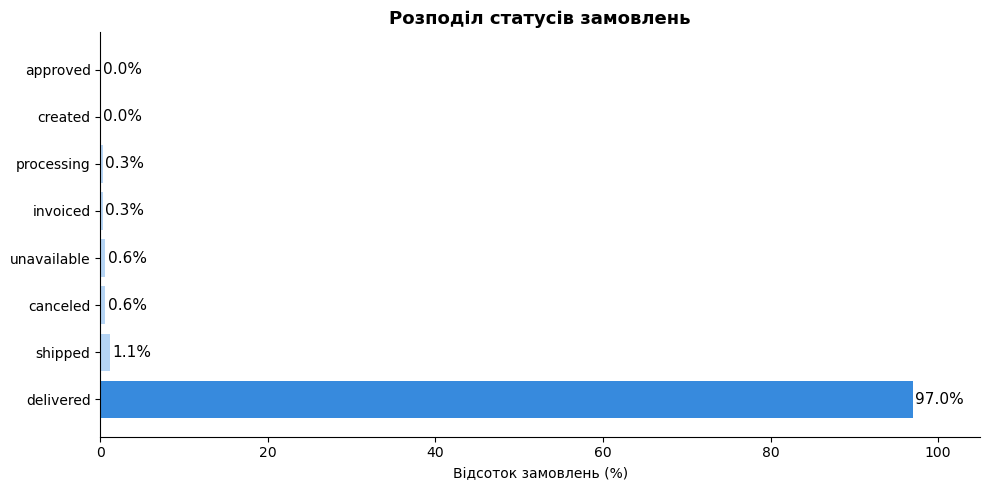

✅ Графік збережено


In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

status = orders["order_status"].value_counts()
status_pct = (status / len(orders) * 100).round(1)

colors = ["#378ADD" if s == "delivered" else "#B5D4F4" for s in status.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(status.index, status_pct.values, color=colors, edgecolor="none")

# підписи значень
for bar, pct in zip(bars, status_pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{pct}%", va="center", fontsize=11)

ax.set_xlabel("Відсоток замовлень (%)")
ax.set_title("Розподіл статусів замовлень", fontsize=13, fontweight="bold")
ax.set_xlim(0, 105)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("status_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Графік збережено")

## Висновки по якості даних

### Джерело даних
- Датасет: Olist Brazilian E-Commerce (Kaggle)
- Часовий діапазон: вересень 2016 - серпень 2018
- Загальна кількість замовлень: 99 441

### 1. Пропущені значення
| Таблиця | Колонка | Пропусків | Висновок |
|---|---|---|---|
| orders | order_delivered_customer_date | 3.0% | Норма - незавершені замовлення |
| orders | order_approved_at | 0.2% | Незначно - технічні збої |
| products | product_name_lenght | 1.9% | Незначно - не всі продавці заповнюють |
| reviews | review_comment_title | 88.3% | Норма - покупці не пишуть заголовок |
| reviews | review_comment_message | 58.7% | Норма - покупці не пишуть коментар |

**Висновок:** критичних пропусків немає. Дані придатні для аналізу.

### 2. Дублікати
Дублікатів по ключових колонках не виявлено в жодній таблиці.

### 3. Статистика цін
- Середня ціна товару: R$ 120.65
- Медіанна ціна: R$ 74.99
- Максимальна ціна: R$ 6 735.00
- Товарів з ціною = 0: немає
- Товарів з ціною > 5000: лише 3 - реальні дорогі товари, залишаємо

**Висновок:** розподіл цін правосторонній - більшість товарів дешеві,
але є дорогі товари які тягнуть середнє вгору. Медіана точніше 
відображає типову ціну.

### 4. Статистика доставки
- Середня затримка: -11.88 днів (негативне = доставлено раніше!)
- Максимальна затримка: +188 днів
- Середній фактичний час доставки: 12 днів

**Висновок:** більшість замовлень доставляється РАНІШЕ очікуваної дати.
Але є критичні випадки затримки до 188 днів - потребують окремого аналізу.

### 5. Статистика відгуків
- Середній рейтинг: 4.09 з 5.0
- Медіана: 5.0 - більше половини покупців ставлять максимальну оцінку
- Поганих відгуків (1-2 зірки): 14.6%

**Висновок:** покупці загалом задоволені сервісом. 
14.6% поганих відгуків - це таргет для ML моделі.

### 6. Статуси замовлень
- Доставлено: 97.0% - основна маса замовлень
- В дорозі: 1.1%
- Скасовано: 0.6%

**Висновок:** для аналізу використовуємо тільки замовлення
зі статусом 'delivered' (96 478 замовлень).

### Загальний висновок
Дані якісні та готові до аналізу. Виявлені пропуски
є природніми для e-commerce датасету і не впливають
на якість аналізу. Переходимо до SQL аналізу та EDA.